# Reconnaissance et analyse automatique d'expressions faciales

**Fondamentaux du Deep Learning** - Master, Semestre 1 (2026-2027)

**Binome :** Mon Watts ([@damonwatts11](https://github.com/damonwatts11)) - Huet ([@SpectreAH](https://github.com/SpectreAH))  
**Formatrice :** Hanane Zerdoum - **Soutenance :** vendredi 9 octobre 2026

---

## Plan du notebook

| Partie | Contenu | Statut |
|:------:|---------|--------|
| 0 | Configuration et imports | - |
| 1 | Recherche, comprehension et preparation des donnees | Obligatoire |
| 2 | Modele de reference (reseau dense) | Obligatoire |
| 3 | Construction d'un CNN avec Keras | Obligatoire |
| 4 | Entrainement du reseau | Obligatoire |
| 5 | Evaluation et analyse des erreurs | Obligatoire |
| 6 | Experimentation et amelioration (>= 3 experiences) | Obligatoire |
| 7 | Enrichissement avec les nouvelles notions | Enrichissement |
| 8 | Detection de plusieurs visages (YOLO) | Extension |
| 9 | Extension a la video | Extension (bonus) |


## 0 - Configuration et imports

Imports communs, graine aleatoire (reproductibilite) et constantes globales du projet.
Sur Google Colab, activez le GPU : *Execution -> Modifier le type d'execution -> GPU*.

In [1]:
# Decommenter sur Colab si besoin :
# !pip install -q ultralytics seaborn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

TensorFlow 2.20.0
GPU disponible : []


In [4]:
pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ------------------

In [ ]:
# --- Reproductibilite ---
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Constantes du projet (dataset : FERPlus) ---
IMG_SIZE    = (48, 48)   # taille d'entree du reseau
CHANNELS    = 1          # 1 = niveaux de gris, 3 = couleur
BATCH_SIZE  = 64
EPOCHS      = 30








# Les 8 classes de FERPlus, dans l'ordre des colonnes de fer2013new.csv
CLASS_NAMES = ['neutre', 'joie', 'surprise', 'tristesse', 'colere', 'degout', 'peur', 'mepris']
NUM_CLASSES = len(CLASS_NAMES)

## 1 - Recherche, comprehension et preparation des donnees

### 1.1 Choix du dataset : FERPlus (FER+)

Nous utilisons **FERPlus**. Ce dataset garde les images de **FER2013** et remplace les labels d'origine par de nouveaux labels, plus fiables.

- Dans FER2013, chaque image a **un seul label**, et ces labels contiennent des erreurs.
- Dans FERPlus, chaque image a ete annotee par **10 personnes**. Le fichier donne le nombre de votes pour chaque expression. Nous gardons l'expression qui a la **majorite des votes**.

FERPlus est donc compose de **deux fichiers** :

| | Images | Labels |
|---|---|---|
| Fichier | `fer2013.csv` | `fer2013new.csv` |
| Source | Competition Kaggle [Facial Expression Recognition Challenge](https://www.kaggle.com/c/challenges-in-representation-learning-facial-expression-recognition-challenge/data) | Depot GitHub [microsoft/FERPlus](https://github.com/microsoft/FERPlus) |
| Auteurs | Pierre-Luc Carrier et Aaron Courville. Article : Goodfellow et al., *Challenges in Representation Learning: A report on three machine learning contests*, 2013 | Barsoum, Zhang, Canton Ferrer et Zhang (Microsoft). Article : *Training Deep Networks for Facial Expression Recognition with Crowd-Sourced Label Distribution*, ICMI 2016 |
| Licence | Donnees diffusees par Kaggle pour la competition (conditions sur la page Kaggle) | MIT |

**Format des donnees**

- **35 887 images** de visages, de taille **48 x 48 pixels**, en **niveaux de gris** (1 seul canal), avec des pixels entre 0 et 255.
- Il n'y a pas de fichiers image (png, jpg). Chaque image est une **ligne du fichier CSV** : la colonne `pixels` contient les 48 x 48 = 2304 valeurs, separees par des espaces.
- La colonne `Usage` indique le role de chaque image : `Training`, `PublicTest` ou `PrivateTest`.
- Dans `fer2013new.csv`, il y a 10 colonnes de votes : les **8 expressions** (neutral, happiness, surprise, sadness, anger, disgust, fear, contempt) et 2 colonnes speciales, `unknown` (expression inconnue) et `NF` (*Not a Face* : l'image n'est pas un visage).
- Les deux fichiers ont le meme nombre de lignes, dans le meme ordre : la ligne *i* de `fer2013new.csv` donne les votes de l'image de la ligne *i* de `fer2013.csv`.

### 1.2 Chargement des deux fichiers

La page de la competition demande un compte Kaggle. Pour que le notebook s'execute de bout en bout, nous telechargeons une copie publique du meme fichier `fer2013.csv` avec `kagglehub`. Le fichier des labels vient directement du depot Microsoft.

In [5]:
import glob
import shutil
import urllib.request

FER_CSV     = 'data/fer2013.csv'      # images (pixels)
FERPLUS_CSV = 'data/fer2013new.csv'   # labels FERPlus (votes des 10 annotateurs)
FERPLUS_URL = 'https://raw.githubusercontent.com/microsoft/FERPlus/master/fer2013new.csv'

os.makedirs('data', exist_ok=True)

# Images : copie Kaggle de fer2013.csv (telechargee une seule fois)
if not os.path.exists(FER_CSV):
    import kagglehub
    dossier = kagglehub.dataset_download('deadskull7/fer2013')
    fichier = glob.glob(os.path.join(dossier, '**', 'fer2013.csv'), recursive=True)[0]
    shutil.copy(fichier, FER_CSV)

# Labels : fichier officiel du depot Microsoft
if not os.path.exists(FERPLUS_CSV):
    urllib.request.urlretrieve(FERPLUS_URL, FERPLUS_CSV)

fer = pd.read_csv(FER_CSV)
ferplus = pd.read_csv(FERPLUS_CSV)

print('fer2013.csv    :', fer.shape, list(fer.columns))
print('fer2013new.csv :', ferplus.shape, list(ferplus.columns))

# Verification : les deux fichiers decrivent les memes images, dans le meme ordre
assert len(fer) == len(ferplus) == 35887
assert (fer['Usage'].values == ferplus['Usage'].values).all()
print('Les deux fichiers sont bien alignes.')

100%|██████████| 96.6M/96.6M [00:02<00:00, 38.1MB/s]

Extracting files...


fer2013.csv    : (35887, 3) ['emotion', 'pixels', 'Usage']
fer2013new.csv : (35887, 12) ['Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF']
Les deux fichiers sont bien alignes.


### 1.3 Construction des labels (vote majoritaire)

Nous appliquons la regle des auteurs de FERPlus (mode *majority*) :

1. un vote isole (une seule personne sur 10) est ignore ;
2. on garde l'image seulement si une expression a **plus de 50 % des votes restants** ;
3. on retire l'image si le gagnant est `unknown` ou `NF`.

Les images sans majorite claire sont retirees : meme les humains ne sont pas d'accord sur leur expression.

In [6]:
VOTE_COLS = ['neutral', 'happiness', 'surprise', 'sadness', 'anger',
             'disgust', 'fear', 'contempt', 'unknown', 'NF']

votes = ferplus[VOTE_COLS].values.astype('float32')    # (35887, 10)

# 1) un vote isole est ignore
votes[votes <= 1] = 0

# 2) une expression doit avoir plus de 50 % des votes restants
total    = votes.sum(axis=1)
gagnant  = votes.argmax(axis=1)                 # indice de la colonne gagnante
majorite = votes.max(axis=1) > 0.5 * total

# 3) le gagnant doit etre une des 8 expressions (pas 'unknown' ni 'NF')
garder = majorite & (gagnant < NUM_CLASSES)

print('Images au depart      :', len(ferplus))
print('Sans majorite claire  :', (~majorite).sum())
print('Majorite unknown / NF :', (majorite & (gagnant >= NUM_CLASSES)).sum())
print('Images gardees        :', garder.sum())

Images au depart      : 35887
Sans majorite claire  : 4200
Majorite unknown / NF : 275
Images gardees        : 31412


In [7]:
# Chaque ligne de 'pixels' est un texte de 2304 valeurs : on le transforme en image 48 x 48
X = np.array([np.array(p.split(), dtype='uint8') for p in fer['pixels']])
X = X.reshape(-1, *IMG_SIZE, CHANNELS)          # (35887, 48, 48, 1)

# On garde seulement les images qui ont un label valide
X     = X[garder]
y     = gagnant[garder]                         # label entier entre 0 et 7
usage = ferplus['Usage'].values[garder]         # Training / PublicTest / PrivateTest

print('X :', X.shape, X.dtype, '| min =', X.min(), '| max =', X.max())
print('y :', y.shape, '| classes :', np.unique(y))

X : (31412, 48, 48, 1) uint8 | min = 0 | max = 255
y : (31412,) | classes : [0 1 2 3 4 5 6 7]


### 1.4 Nombre d'images par classe

           train  validation  test  total      %
neutre      8740        1182  1090  11012  35.06
joie        7287         865   893   9045  28.79
surprise    3149         415   396   3960  12.61
tristesse   3014         351   384   3749  11.93
colere      2100         287   273   2660   8.47
degout       119          24    18    161   0.51
peur         532          62    83    677   2.16
mepris       119          13    16    148   0.47

train         25060
validation     3199
test           3153
total         31412
dtype: int64


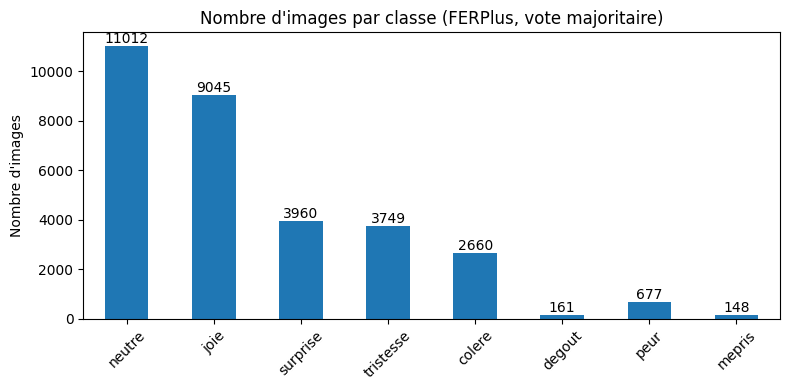

In [8]:
counts = pd.crosstab(y, usage)[['Training', 'PublicTest', 'PrivateTest']]
counts.index = CLASS_NAMES
counts.columns = ['train', 'validation', 'test']
counts['total'] = counts.sum(axis=1)
counts['%'] = (100 * counts['total'] / counts['total'].sum()).round(2)

print(counts)
print()
print(counts[['train', 'validation', 'test', 'total']].sum())

ax = counts['total'].plot(kind='bar', figsize=(8, 4))
ax.bar_label(ax.containers[0])
plt.title("Nombre d'images par classe (FERPlus, vote majoritaire)")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 1.5 Exemples d'images pour chaque classe

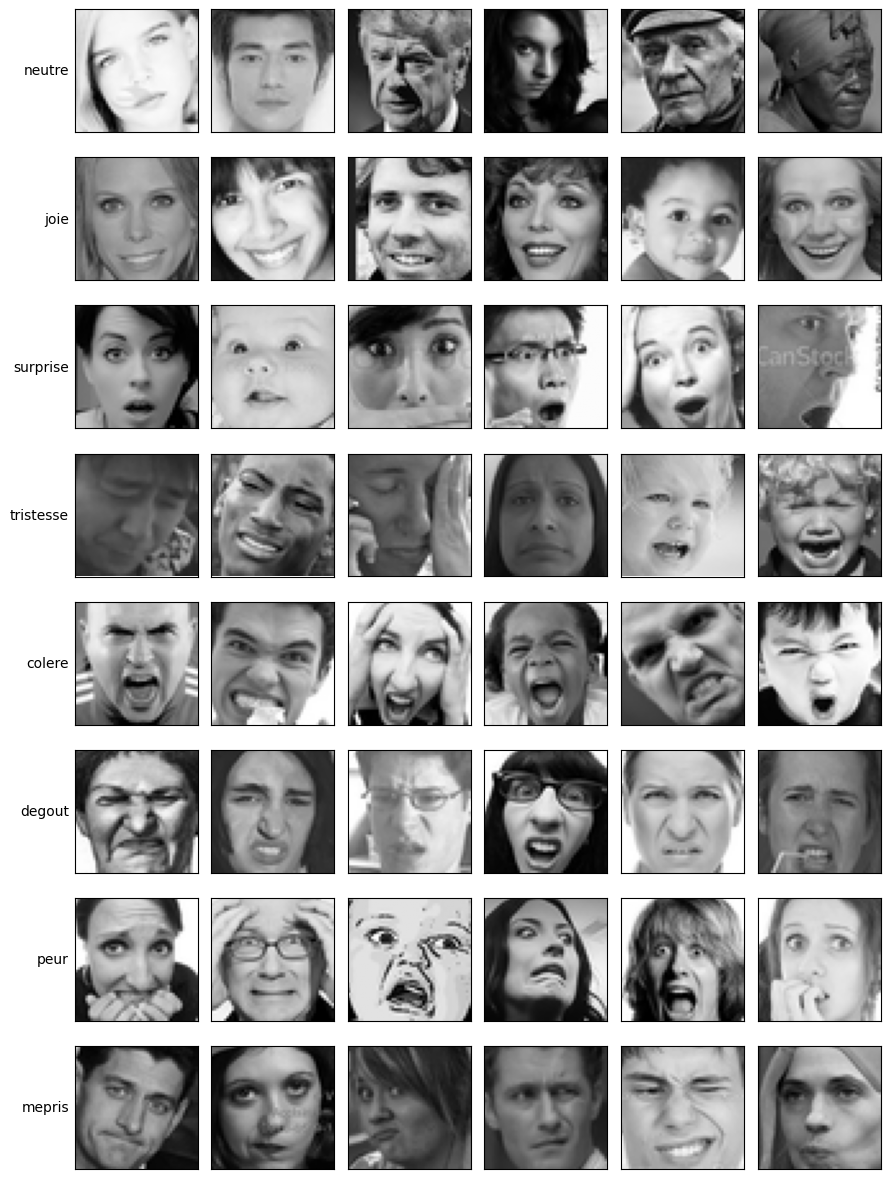

In [9]:
N_EX = 6
rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(NUM_CLASSES, N_EX, figsize=(1.5 * N_EX, 1.5 * NUM_CLASSES))
for i, cls in enumerate(CLASS_NAMES):
    idx = rng.choice(np.where(y == i)[0], size=N_EX, replace=False)
    for j, k in enumerate(idx):
        axes[i, j].imshow(X[k].squeeze(), cmap='gray', vmin=0, vmax=255)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
    axes[i, 0].set_ylabel(cls, rotation=0, ha='right', va='center')
plt.tight_layout()
plt.show()

### 1.6 Bilan du dataset

Apres le vote majoritaire, il reste **31 412 images** sur 35 887 (4 475 images retirees : 4 200 sans majorite claire et 275 classees `unknown` ou `NF`).

| Classe | train | validation | test | total | % |
|---|---:|---:|---:|---:|---:|
| neutre | 8 740 | 1 182 | 1 090 | 11 012 | 35,06 |
| joie | 7 287 | 865 | 893 | 9 045 | 28,79 |
| surprise | 3 149 | 415 | 396 | 3 960 | 12,61 |
| tristesse | 3 014 | 351 | 384 | 3 749 | 11,93 |
| colere | 2 100 | 287 | 273 | 2 660 | 8,47 |
| degout | 119 | 24 | 18 | 161 | 0,51 |
| peur | 532 | 62 | 83 | 677 | 2,16 |
| mepris | 119 | 13 | 16 | 148 | 0,47 |
| **Total** | **25 060** | **3 199** | **3 153** | **31 412** | **100** |

**Desequilibre entre les classes.** Le dataset est tres desequilibre :

- `neutre` et `joie` representent a elles deux environ **64 %** des images ;
- `degout` et `mepris` ont chacune environ **0,5 %** des images (161 et 148 images) ;
- il y a environ **74 fois plus** d'images `neutre` que d'images `mepris`.

**Consequences pour la suite.**

- L'accuracy seule peut tromper : un modele qui repond toujours `neutre` aurait deja environ 35 % d'accuracy sur le test (1 090 / 3 153), sans rien reconnaitre.
- Les classes rares (`degout`, `mepris`, `peur`) seront plus difficiles a apprendre. Il faudra regarder les resultats **classe par classe** (partie 5) et tester des solutions (partie 6).

### 1.7 Preparation des donnees

| Etape | Ce que nous faisons | Role |
|---|---|---|
| Redimensionnement | Aucun : toutes les images font deja 48 x 48 | L'entree du reseau a une taille fixe `(48, 48, 1)`. Les visages detectes dans la partie 8 devront etre ramenes a cette taille. |
| Normalisation | Division des pixels par 255 | Les pixels passent de [0, 255] a [0, 1]. Des entrees petites et sur la meme echelle rendent la descente de gradient plus stable et plus rapide. |
| Labels | Vote majoritaire (partie 1.3) | Chaque image recoit un entier entre 0 et 7. |
| Encodage | One-hot avec `to_categorical` | La sortie du reseau est un vecteur de 8 probabilites (Softmax). Le label doit avoir la meme forme pour calculer la `categorical_crossentropy`. Exemple : 2 devient `[0, 0, 1, 0, 0, 0, 0, 0]`. |
| Train / validation / test | Decoupage officiel de la colonne `Usage` | `Training` -> train, `PublicTest` -> validation, `PrivateTest` -> test. |

**Pourquoi le decoupage officiel ?** C'est celui des auteurs de FER2013 et de FERPlus, donc nos resultats restent comparables. Chaque image est dans un seul ensemble.

- **train** : les images sur lesquelles le modele apprend ;
- **validation** : sert a suivre l'apprentissage et a comparer les modeles ;
- **test** : reserve a l'evaluation finale. Il ne sert jamais pendant l'entrainement ni pour choisir un modele.

In [10]:
# --- Normalisation : pixels entre 0 et 1 ---
X = X.astype('float32') / 255.0

# --- Encodage one-hot des labels ---
y_cat = keras.utils.to_categorical(y, NUM_CLASSES)
print('Exemple de label :', y[0], '(' + CLASS_NAMES[y[0]] + ') ->', y_cat[0])

# --- Decoupage officiel train / validation / test ---
is_train = usage == 'Training'
is_val   = usage == 'PublicTest'
is_test  = usage == 'PrivateTest'

X_train, y_train = X[is_train], y_cat[is_train]
X_val,   y_val   = X[is_val],   y_cat[is_val]
X_test,  y_test  = X[is_test],  y_cat[is_test]

print('train      :', X_train.shape, y_train.shape)
print('validation :', X_val.shape, y_val.shape)
print('test       :', X_test.shape, y_test.shape)
print('pixels     : min =', X_train.min(), '| max =', X_train.max())

Exemple de label : 0 (neutre) -> [1. 0. 0. 0. 0. 0. 0. 0.]
train      : (25060, 48, 48, 1) (25060, 8)
validation : (3199, 48, 48, 1) (3199, 8)
test       : (3153, 48, 48, 1) (3153, 8)
pixels     : min = 0.0 | max = 1.0


## 2 - Modele de reference (reseau dense)

Reseau simple servant de **point de comparaison** avec le CNN.  
`Image -> Flatten -> Dense + activation -> Dense -> Softmax`

A savoir expliquer : transformation de l'image en entree, poids et biais, propagation avant, fonctions d'activation, fonction de perte, retropropagation, descente de gradient, sortie multiclasse (Softmax).

In [11]:
def build_baseline():
    model = keras.Sequential([
        keras.Input(shape=(*IMG_SIZE, CHANNELS)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name='baseline_dense')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

baseline = build_baseline()
baseline.summary()

Model: "baseline_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,136 (2.26 MB)

 Trainable params: 592,136 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

## 3 - Construction d'un CNN avec Keras

Proposez **et justifiez** votre propre architecture (plusieurs blocs conv + pooling).  
`Conv2D+ReLU -> MaxPooling -> Conv2D+ReLU -> MaxPooling -> Flatten -> Dense -> Softmax`

A expliquer : filtres, convolution, feature maps, kernel, stride, padding, ReLU, pooling, Flatten, Dense, couche de sortie. Suivez l'evolution des **dimensions** et le **nombre de parametres** couche par couche (`model.summary()`).

In [12]:
def build_cnn():
    model = keras.Sequential([
        keras.Input(shape=(*IMG_SIZE, CHANNELS)),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name='cnn')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn = build_cnn()
cnn.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,552 (2.61 MB)

 Trainable params: 684,104 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

## 4 - Entrainement du reseau

Justifiez : fonction de perte, optimiseur, batch size, nombre d'epoques, metriques.  
Etudiez les courbes **loss / accuracy** (train vs validation) et identifiez un eventuel **surapprentissage**.

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5),
]

history = cnn.fit(X_train, y_train,
                   validation_data=(X_val, y_val),
                   epochs=EPOCHS, batch_size=BATCH_SIZE,
                   callbacks=callbacks)

Epoch 1/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 96s 232ms/step - accuracy: 0.4375 - loss: 1.5769 - val_accuracy: 0.3795 - val_loss: 1.5839 - learning_rate: 0.0010
Epoch 2/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 110s 280ms/step - accuracy: 0.5660 - loss: 1.2554 - val_accuracy: 0.6321 - val_loss: 1.0641 - learning_rate: 0.0010
Epoch 3/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 105s 266ms/step - accuracy: 0.6091 - loss: 1.1243 - val_accuracy: 0.6471 - val_loss: 1.0962 - learning_rate: 0.0010
Epoch 4/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 110s 280ms/step - accuracy: 0.6437 - loss: 1.0168 - val_accuracy: 0.6577 - val_loss: 0.9840 - learning_rate: 0.0010
Epoch 5/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 112s 285ms/step - accuracy: 0.6681 - loss: 0.9467 - val_accuracy: 0.6524 - val_loss: 0.9512 - learning_rate: 0.0010
Epoch 6/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 194s 495ms/step - accuracy: 0.6933 - loss: 0.8688 - val_accuracy: 0.6824 - val_loss: 0.9702 - learning_rate: 0.0010
Epoch 7/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 247s 610ms/step - accurac

In [ ]:
def plot_history(history):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h['loss'], label='train'); ax[0].plot(h['val_loss'], label='val')
    ax[0].set_title('Loss'); ax[0].legend()
    ax[1].plot(h['accuracy'], label='train'); ax[1].plot(h['val_accuracy'], label='val')
    ax[1].set_title('Accuracy'); ax[1].legend()
    plt.show()
    
    plot_history(history)

## 5 - Evaluation et analyse des erreurs

L'accuracy seule ne suffit pas (classes desequilibrees). Produisez une **matrice de confusion** et analysez : expressions bien reconnues, souvent confondues, les plus difficiles. Affichez des exemples `image + vraie classe + classe predite + probabilite`, dont plusieurs **erreurs**.

In [15]:
# --- Evaluation sur le test ---
# test_loss, test_acc = cnn.evaluate(X_test, y_test)
# y_pred = cnn.predict(X_test)
# y_pred_cls = y_pred.argmax(1); y_true_cls = y_test.argmax(1)
#
# print(classification_report(y_true_cls, y_pred_cls, target_names=CLASS_NAMES))
#
# cm = confusion_matrix(y_true_cls, y_pred_cls)
# sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
# plt.xlabel('Predit'); plt.ylabel('Vrai'); plt.show()

## 6 - Experimentation et amelioration

**Au minimum 3 experiences**, en ne modifiant qu'un nombre limite de parametres a la fois (couches, filtres, kernels, pooling, neurones, batch size, learning rate, optimiseur, epoques) ou techniques (Dropout, Data Augmentation, Early Stopping, regularisation).

Presentez un **tableau comparatif** et justifiez le modele final.

| # | Modification | Val. accuracy | Observations |
|:-:|--------------|:-------------:|--------------|
| 1 | _(baseline CNN)_ | | |
| 2 | | | |
| 3 | | | |

In [16]:
# --- Exemple : Data Augmentation ---
# data_aug = keras.Sequential([
#     layers.RandomFlip('horizontal'),
#     layers.RandomRotation(0.1),
#     layers.RandomZoom(0.1),
# ])
# Inserer data_aug juste apres la couche Input du CNN pour l'experience correspondante.

## 7 - Enrichissement avec les nouvelles notions

Pistes : Data Augmentation, **Transfer Learning** (reseaux pre-entraines), regularisation, detection d'objets, YOLO.

In [17]:
# --- Exemple : Transfer Learning (necessite CHANNELS = 3) ---
# base = keras.applications.MobileNetV2(
#     input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
# base.trainable = False
# tl = keras.Sequential([
#     base, layers.GlobalAveragePooling2D(),
#     layers.Dense(128, activation='relu'), layers.Dropout(0.3),
#     layers.Dense(NUM_CLASSES, activation='softmax')])
# tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## 8 - Extension : detection de plusieurs visages (YOLO)

`Image -> detection des visages -> bounding boxes -> extraction -> CNN -> expressions`

**Attention** : un YOLO standard (COCO) detecte des *personnes*, pas des *visages*. Utilisez un modele entraine aux visages (ou justifiez une autre solution). Chaque visage extrait doit subir **exactement le meme pretraitement** que les images d'entrainement.

Notions : classification vs detection, bounding box, confidence score, IoU, NMS, modele pre-entraine, (fine-tuning), precision/recall/mAP.

In [18]:
# from ultralytics import YOLO
# detector = YOLO('yolov8n-face.pt')  # modele de detection de visages
#
# def analyser_image(img):
#     results = detector(img)
#     for box in results[0].boxes:
#         x1, y1, x2, y2 = map(int, box.xyxy[0])
#         visage = img[y1:y2, x1:x2]
#         # MEME pretraitement que l'entrainement (resize, gris/couleur, /255)
#         # pred = cnn.predict(prep(visage))
#         # dessiner la box + CLASS_NAMES[pred.argmax()] + score
#     return img

## 9 - Extension a la video (bonus)

`Video -> images successives -> detection -> extraction -> CNN -> predictions -> affichage`

In [19]:
# import cv2
# cap = cv2.VideoCapture('data/demo.mp4')
# while cap.isOpened():
#     ok, frame = cap.read()
#     if not ok: break
#     frame = analyser_image(frame)
#     # ecrire / afficher la frame annotee
# cap.release()

## Conclusion

Neurone -> MLP -> Backpropagation -> Keras -> CNN -> Convolution -> Classification multiclasse -> Softmax -> Amelioration -> Detection -> YOLO -> Application complete de vision par ordinateur.

**Livrables (soutenance 9 oct. 2026)** : notebook executable de bout en bout, presentation, demonstration du modele final.